### Loading JSON files and producing combined plot

- load saved summary files
- combine summaries into 1 plot
- save final plot

In [14]:
# Imports for functionality
import json
import matplotlib.pyplot as plt

#### Experiment 1

In [10]:
paths = [
    r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp1results1_ts_exponent1.5.json",
    r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp1results2_psd_exponent1.5.json",
    r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp1results3_specmod_exponent1.5.json",
]

results_combined = []

for p in paths:
    with open(p, "r") as f:
        results_combined.append(json.load(f))

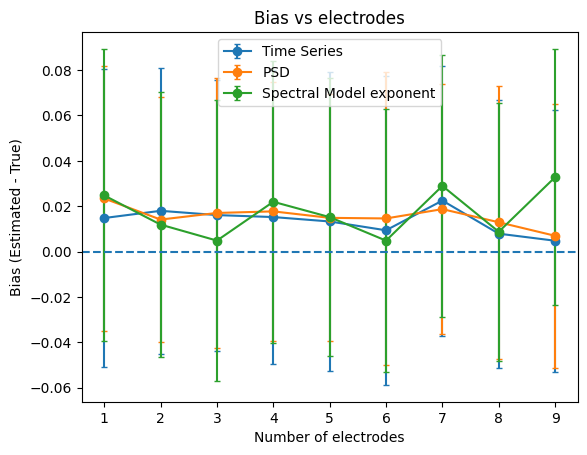

In [21]:
labels = ["Time Series", "PSD", "Spectral Model exponent"]

fig, ax = plt.subplots()

for path, label in zip(paths, labels):

    with open(path, "r") as f:
        r = json.load(f)

    x = r["electrodes"]
    bias = r["errors"]

    yerr = r.get("stds", None)

    if yerr is not None:
        plt.errorbar(x, bias, yerr=yerr, marker="o", capsize=2, label=label)
    else:
        plt.plot(x, bias, marker="o", label=label)

plt.axhline(0, linestyle="--")

plt.xlabel("Number of electrodes")
plt.ylabel("Bias (Estimated - True)")
plt.title("Bias vs electrodes")
plt.legend()
plt.show()

fig.savefig(r"C:\Users\chloe\DissertationSimulations\Figures\1D electrodes\Combined plots\exp1_combined_plot_1D_exponent-1.5.png", dpi=300, bbox_inches="tight")

#### Experiment 2

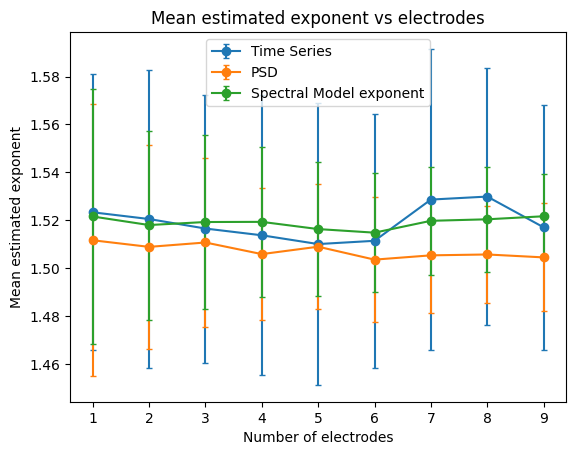

In [23]:
import matplotlib.pyplot as plt
import json

paths = [
    r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp2results1_ts_exp_matrix_radial_-0.5-2.json",
    r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp2results2_psd_exp_matrix_radial_-0.5-2.json",
    r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp2results3_specmod_exp_matrix_radial_-0.5-2.json",
]

labels = ["Time Series", "PSD", "Spectral Model exponent"]

fig, ax = plt.subplots()

for path, label in zip(paths, labels):

    with open(path, "r") as f:
        r = json.load(f)

    x = r["electrodes"]
    means = r["means"]
    yerr = r.get("stds", None)

    if yerr is not None:
        ax.errorbar(x, means, yerr=yerr, marker="o", capsize=2, label=label)

    else:
        ax.plot(x,means, marker="o", label=label)

ax.set_xlabel("Number of electrodes")
ax.set_ylabel("Mean estimated exponent")
ax.set_title("Mean estimated exponent vs electrodes")
ax.legend()
plt.show()

fig.savefig(r"C:\Users\chloe\DissertationSimulations\Figures\1D electrodes\Combined plots\exp2_combined_plot_1D_exp_matrix_radial_-0.5-2.png", dpi=300, bbox_inches="tight")